<a href="https://colab.research.google.com/github/emilyrgarman/ml3finalproject_triage/blob/main/XGBOOST_CLINICALBERT_BUILDING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## XGBoost + Clinical Bert Model Building
For comparison to ANN for tabular data

In [1]:
! git clone https://github.com/emilyrgarman/ml3finalproject_triage.git

Cloning into 'ml3finalproject_triage'...
remote: Enumerating objects: 87, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 87 (delta 41), reused 24 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (87/87), 9.28 MiB | 18.23 MiB/s, done.
Resolving deltas: 100% (41/41), done.


In [2]:
import pandas as pd
import numpy as np
import random
import re
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

SEED = 42

Loading in data

In [3]:
tab_data = pd.read_csv('/content/ml3finalproject_triage/train.csv')
complaints = pd.read_csv('/content/ml3finalproject_triage/chief_complaints.csv')
history = pd.read_csv('/content/ml3finalproject_triage/patient_history.csv')

Preprocessing

In [4]:
SEVERITY_WORDS = ['mild', 'moderate', 'severe',
                  'critical', 'minor', 'major', 'actively',
                  'intermittent', 'in known patient']

def clean_complaint(x):
    x = re.split(r'[,，]', x)[0]
    return re.sub('|'.join(SEVERITY_WORDS), '', x, flags=re.IGNORECASE).strip()

complaints['cc_stripped'] = complaints['chief_complaint_raw'].apply(clean_complaint)
print(len(complaints))

100000


In [5]:
complaints = complaints.drop_duplicates(subset=['cc_stripped'])
print(len(complaints))

1973


In [6]:
df = tab_data.merge(complaints[['patient_id', 'cc_stripped']], on='patient_id', how='inner')
df = df.merge(history, on='patient_id', how='inner')

In [7]:
# ── Columns ────────────────────────────────────────────────
NUMERIC_COLS = ['age', 'num_active_medications', 'num_comorbidities',
                'systolic_bp', 'diastolic_bp', 'heart_rate',
                'respiratory_rate', 'temperature_c', 'spo2',
                'gcs_total', 'pain_score', 'bmi',
                'num_prior_ed_visits_12m', 'num_prior_admissions_12m']
CATEG_COLS   = ['arrival_mode', 'sex', 'transport_origin',
                'pain_location', 'mental_status_triage']
DUMMY_COLS   = ['hx_hypertension', 'hx_diabetes_type2', 'hx_diabetes_type1',
                'hx_asthma', 'hx_copd', 'hx_heart_failure', 'hx_atrial_fibrillation',
                'hx_ckd', 'hx_liver_disease', 'hx_malignancy', 'hx_obesity',
                'hx_depression', 'hx_anxiety', 'hx_dementia', 'hx_epilepsy',
                'hx_hypothyroidism', 'hx_hyperthyroidism', 'hx_hiv', 'hx_coagulopathy',
                'hx_immunosuppressed', 'hx_pregnant', 'hx_substance_use_disorder',
                'hx_coronary_artery_disease', 'hx_stroke_prior',
                'hx_peripheral_vascular_disease']

TARGET_COL = 'triage_acuity'
TEXT_COL   = 'cc_stripped'
TABULAR_COLS = NUMERIC_COLS + CATEG_COLS + DUMMY_COLS

# ── Encode categorical columns ───────────────────────────
for col in CATEG_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# ── Tabular preprocessing ────────────────────────────────
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()
X_tab = scaler.fit_transform(imputer.fit_transform(df[TABULAR_COLS]))

# ── Labels ───────────────────────────────────────────────
y = df[TARGET_COL].values - 1  # shift 1–5 → 0–4 for CrossEntropyLoss

# ── Split into train, val, test ──────────────────────────
# stratify ensures class distribution is preserved
X_temp, X_test, y_temp, y_test, texts_temp, texts_test = train_test_split(
    X_tab, y, df[TEXT_COL].fillna('').values,
    test_size=0.1, random_state=42, stratify=y
)

X_tr, X_val, y_tr, y_val, texts_tr, texts_val = train_test_split(
    X_temp, y_temp, texts_temp,
    test_size=0.2, random_state=42, stratify=y_temp
)

# ── Verification ─────────────────────────────────────────
overlap_train_val = set(texts_tr) & set(texts_val)
overlap_train_test = set(texts_tr) & set(texts_test)
overlap_val_test = set(texts_val) & set(texts_test)

print(f"Train: {len(y_tr)} | Val: {len(y_val)} | Test: {len(y_test)}")
print(f"Overlap Train/Val: {len(overlap_train_val)}")
print(f"Overlap Train/Test: {len(overlap_train_test)}")
print(f"Overlap Val/Test: {len(overlap_val_test)}")

Train: 1414 | Val: 354 | Test: 197
Overlap Train/Val: 0
Overlap Train/Test: 0
Overlap Val/Test: 0


In [8]:
# ── Clinical abbreviations ─────────────────────────────────────────
ABBREV_MAP = {
    'with': 'w/',
    'without': 'w/o',
    'history of': 'hx of',
    'complaint of': 'c/o',
    'shortness of breath': 'SOB',
    'loss of consciousness': 'LOC',
    'atrial fibrillation': 'AF',
    'diabetic ketoacidosis': 'DKA',
    'urinary tract infection': 'UTI',
    'motor vehicle accident': 'MVA',
    'chest pain': 'CP',
    'blood pressure': 'BP',
    'heart rate': 'HR',
    'nausea and vomiting': 'N&V',
    'upper respiratory tract infection': 'URTI',
    'shortness of breath': 'SOB',
    'gastrointestinal': 'GI',
    'myocardial infarction': 'MI',
    'pulmonary embolism': 'PE',
    'deep vein thrombosis': 'DVT',
    'electrocardiogram': 'ECG',
    'fracture': 'frx',
    'laceration': 'lac',
    'abdominal': 'abd',
    'bilateral': 'bil',
}

# ── Typos ──────────────────────────────────────────────────────────
TYPO_MAP = {
    'fever': ['fevre', 'fver', 'fevr'],
    'pain': ['paon', 'pian', 'pan'],
    'vomiting': ['vomitting', 'vomitng', 'vomitin'],
    'breathing': ['breathng', 'brething', 'breathin'],
    'headache': ['headach', 'headche', 'hedache'],
    'abdominal': ['abdomnal', 'abdomial', 'abdomianl'],
    'dizziness': ['dizzness', 'diziness', 'dizzines'],
    'swelling': ['sweling', 'swlling', 'sweeling'],
    'bleeding': ['bleeing', 'bleding', 'bleedin'],
    'fracture': ['fractue', 'fractrure', 'fractyre'],
    'infection': ['infecton', 'infeccion', 'infectoin'],
    'severe': ['severre', 'seveer', 'sevre'],
    'chronic': ['chronc', 'chornic', 'chonic'],
    'acute': ['acuте', 'acte', 'acut'],
    'nausea': ['nasea', 'nauseau', 'nasuea'],
    'laceration': ['laceraion', 'lacerartion', 'laceraton'],
    'palpitations': ['palpitaions', 'palpitaitons', 'palpitatons'],
    'dyspnoea': ['dyspnoea', 'dyspnea', 'dispnoea'],
    'haemorrhage': ['haemmorhage', 'heamorrhage', 'haemorrhge'],
}

def abbreviate(text, p=0.5):
    for term, abbrev in ABBREV_MAP.items():
        if term in text.lower() and random.random() < p:
            text = re.sub(term, abbrev, text, flags=re.IGNORECASE)
    return text

def add_typos(text, p=0.2):
    words = text.split()
    for i, word in enumerate(words):
        if word.lower() in TYPO_MAP and random.random() < p:
            words[i] = random.choice(TYPO_MAP[word.lower()])
    return ' '.join(words)

def augment(text):
    r = random.random()
    if r < 0.4:
        text = abbreviate(text, p=0.8)    # heavy abbreviation
    elif r < 0.7:
        text = add_typos(text, p=0.3)     # some typos
    elif r < 0.9:
        text = abbreviate(text, p=0.4)    # light abbreviation
        text = add_typos(text, p=0.1)     # plus occasional typo
    # else 10% → return text unchanged
    return text

# ── Apply to train only ────────────────────────────────────────────
aug_texts  = [augment(t) for t in texts_tr]
aug_labels = y_tr.copy()

texts_tr_aug = aug_texts.copy()
y_tr_aug     = aug_labels.copy()

XGBoost Model Building

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report

# ----- Model definition & training -----
xgb_clf = xgb.XGBClassifier(
    objective = 'multi:softprob',  # outputs class probabilities
    num_class = 5,
    n_estimators = 500,
    max_depth = 6,
    learning_rate = 0.05,
    subsample = 0.8,
    colsample_bytree = 0.8,
    reg_alpha = 0.1,               # L1 regularization
    reg_lambda = 1.0,               # L2 regularization
    eval_metric = 'mlogloss',
    early_stopping_rounds = 20,
    random_state = SEED,
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
)

xgb_clf.fit(
    X_tr,  y_tr,
    eval_set = [(X_val, y_val)],
    verbose  = 50
)

print('Training complete. Best val loss:',
      round(xgb_clf.best_score, 4))

# ----- DataLoaders -----
def make_loader(X, y=None, batch_size=256, shuffle=False):
    Xt = torch.tensor(X, dtype=torch.float32)
    if y is not None:
        yt = torch.tensor(y.squeeze(), dtype=torch.long)
        return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)
    return DataLoader(TensorDataset(Xt), batch_size=batch_size)


DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'


# ----- Evaluation -----
xgb_val_preds = xgb_clf.predict(X_val)
f1 = f1_score(y_val, xgb_val_preds, average='macro')
print(f'XGBoost-only Val Macro-F1: {f1:.4f}')
print(classification_report(y_val, xgb_val_preds,
                             target_names=[f'Acuity {i+1}' for i in range(5)]))



xgb_val_probs  = xgb_clf.predict_proba(X_val)       # (n_val,  5)
xgb_test_probs = xgb_clf.predict_proba(X_test)      # (n_test, 5)

[0]	validation_0-mlogloss:1.53333
[50]	validation_0-mlogloss:0.50526
[100]	validation_0-mlogloss:0.39075
[150]	validation_0-mlogloss:0.37706
[194]	validation_0-mlogloss:0.37695
Training complete. Best val loss: 0.3754
XGBoost-only Val Macro-F1: 0.8427
              precision    recall  f1-score   support

    Acuity 1       0.96      0.96      0.96        72
    Acuity 2       0.94      0.91      0.93        75
    Acuity 3       0.81      0.84      0.82        75
    Acuity 4       0.73      0.66      0.69        73
    Acuity 5       0.77      0.86      0.82        59

    accuracy                           0.84       354
   macro avg       0.84      0.85      0.84       354
weighted avg       0.84      0.84      0.84       354



ClinicalBERT

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 1.4442 | Val Loss: 1.1048 | Val Macro-F1: 0.4997
Epoch 02 | Train Loss: 0.9422 | Val Loss: 0.6834 | Val Macro-F1: 0.7191
Epoch 03 | Train Loss: 0.5808 | Val Loss: 0.3733 | Val Macro-F1: 0.8840
Epoch 04 | Train Loss: 0.2791 | Val Loss: 0.1771 | Val Macro-F1: 0.9461
Epoch 05 | Train Loss: 0.1381 | Val Loss: 0.1299 | Val Macro-F1: 0.9664
Epoch 06 | Train Loss: 0.0902 | Val Loss: 0.0598 | Val Macro-F1: 0.9891
Epoch 07 | Train Loss: 0.0751 | Val Loss: 0.0779 | Val Macro-F1: 0.9781
           | No improvement. Patience: 1/3
Epoch 08 | Train Loss: 0.0534 | Val Loss: 0.0731 | Val Macro-F1: 0.9807
           | No improvement. Patience: 2/3
Epoch 09 | Train Loss: 0.0391 | Val Loss: 0.0713 | Val Macro-F1: 0.9861
           | No improvement. Patience: 3/3
Early stopping at epoch 9.
Training complete. Best val loss: 0.0598


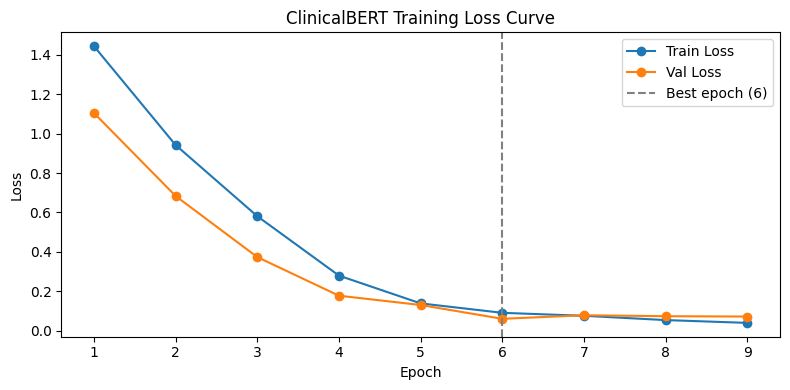

In [11]:
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt

BERT_MODEL = 'emilyalsentzer/Bio_ClinicalBERT'
MAX_LEN    = 32

tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

# ── Dataset ────────────────────────────────────────────────────────
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels=None):
        self.texts  = list(texts)
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(self.texts[idx], max_length=MAX_LEN,
                        padding='max_length', truncation=True,
                        return_tensors='pt')
        item = {k: v.squeeze(0) for k, v in enc.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# ── Model ──────────────────────────────────────────────────────────
class ClinicalBERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes=5, dropout=0.1):
        super().__init__()
        self.bert    = AutoModel.from_pretrained(model_name)
        hidden_size  = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.clf     = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        out     = self.bert(input_ids=input_ids,
                            attention_mask=attention_mask,
                            token_type_ids=token_type_ids)
        cls_emb = out.last_hidden_state[:, 0, :]
        logits  = self.clf(self.dropout(cls_emb))
        return logits, cls_emb

# ── DataLoaders ────────────────────────────────────────────────────
tr_text_ds  = TextDataset(texts_tr_aug, y_tr_aug.squeeze())
val_text_ds = TextDataset(texts_val, y_val.squeeze())

tr_text_loader  = DataLoader(tr_text_ds,  batch_size=64, shuffle=True)
val_text_loader = DataLoader(val_text_ds, batch_size=64)

# ── Training ───────────────────────────────────────────────────────
BERT_EPOCHS = 50
PATIENCE    = 3

bert_clf       = ClinicalBERTClassifier(BERT_MODEL).to(DEVICE)
bert_optimizer = torch.optim.AdamW(bert_clf.parameters(), lr=2e-5, weight_decay=1e-2)
class_counts = np.bincount(y_tr_aug)
weights = 1.0 / class_counts
weights = weights / weights.sum()
bert_criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(DEVICE))
bert_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(bert_optimizer, T_max=BERT_EPOCHS)

best_bert_loss  = float('inf')
best_bert_state = None
patience_count  = 0
train_losses    = []
val_losses      = []

for epoch in range(1, BERT_EPOCHS + 1):
    # ── Train ──
    bert_clf.train()
    epoch_train_loss = 0
    for batch in tr_text_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        labels    = batch['labels'].to(DEVICE)

        bert_optimizer.zero_grad()
        logits, _ = bert_clf(input_ids, attn_mask)
        loss      = bert_criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_clf.parameters(), max_norm=1.0)
        bert_optimizer.step()
        epoch_train_loss += loss.item()

    epoch_train_loss /= len(tr_text_loader)
    train_losses.append(epoch_train_loss)
    bert_scheduler.step()  # epoch-level

    # ── Validate ──
    bert_clf.eval()
    val_loss, preds, trues = 0, [], []
    with torch.no_grad():
        for batch in val_text_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attn_mask = batch['attention_mask'].to(DEVICE)
            labels    = batch['labels'].to(DEVICE)
            logits, _ = bert_clf(input_ids, attn_mask)
            val_loss += bert_criterion(logits, labels).item()
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(labels.cpu().numpy())

    val_loss /= len(val_text_loader)
    val_losses.append(val_loss)
    f1 = f1_score(trues, preds, average='macro')
    print(f'Epoch {epoch:02d} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Macro-F1: {f1:.4f}')

    # ── Early stopping ──
    if val_loss < best_bert_loss:
        best_bert_loss  = val_loss
        best_bert_state = bert_clf.state_dict()
        patience_count  = 0
    else:
        patience_count += 1
        print(f'           | No improvement. Patience: {patience_count}/{PATIENCE}')
        if patience_count >= PATIENCE:
            print(f'Early stopping at epoch {epoch}.')
            break

bert_clf.load_state_dict(best_bert_state)
print('Training complete. Best val loss:', round(best_bert_loss, 4))

# ── Loss curve ─────────────────────────────────────────────────────
epochs_ran = range(1, len(train_losses) + 1)
best_epoch = val_losses.index(best_bert_loss) + 1

plt.figure(figsize=(8, 4))
plt.plot(epochs_ran, train_losses, label='Train Loss', marker='o')
plt.plot(epochs_ran, val_losses,   label='Val Loss',   marker='o')
plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ClinicalBERT Training Loss Curve')
plt.legend()
plt.tight_layout()
plt.savefig('bert_loss_curve.png', dpi=150)
plt.show()

# ── Get probabilities and embeddings for fusion ────────────────────
def get_bert_probs_and_embeddings(model, texts, labels=None):
    model.eval()
    ds     = TextDataset(texts, labels)
    loader = DataLoader(ds, batch_size=32)
    probs, embeddings = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attn_mask = batch['attention_mask'].to(DEVICE)
            logits, cls_emb = model(input_ids, attn_mask)
            probs.append(torch.softmax(logits, dim=1).cpu().numpy())
            embeddings.append(cls_emb.cpu().numpy())
    return np.vstack(probs), np.vstack(embeddings)

bert_val_probs,  bert_val_embs  = get_bert_probs_and_embeddings(bert_clf, texts_val)
bert_test_probs, bert_test_embs = get_bert_probs_and_embeddings(bert_clf, texts_test)

Fusion and results

Epoch 01 | Train Loss: 0.6537 | Val Loss: 0.3787 | Val Macro-F1: 0.9861
Epoch 02 | Train Loss: 0.1933 | Val Loss: 0.0988 | Val Macro-F1: 0.9861
Epoch 03 | Train Loss: 0.1257 | Val Loss: 0.0711 | Val Macro-F1: 0.9861
Epoch 04 | Train Loss: 0.0940 | Val Loss: 0.0659 | Val Macro-F1: 0.9861
Epoch 05 | Train Loss: 0.0821 | Val Loss: 0.0634 | Val Macro-F1: 0.9861
Epoch 06 | Train Loss: 0.0683 | Val Loss: 0.0621 | Val Macro-F1: 0.9861
Epoch 07 | Train Loss: 0.0561 | Val Loss: 0.0605 | Val Macro-F1: 0.9861
Epoch 08 | Train Loss: 0.0542 | Val Loss: 0.0591 | Val Macro-F1: 0.9861
Epoch 09 | Train Loss: 0.0497 | Val Loss: 0.0577 | Val Macro-F1: 0.9861
Epoch 10 | Train Loss: 0.0542 | Val Loss: 0.0570 | Val Macro-F1: 0.9861
Epoch 11 | Train Loss: 0.0446 | Val Loss: 0.0554 | Val Macro-F1: 0.9861
Epoch 12 | Train Loss: 0.0455 | Val Loss: 0.0550 | Val Macro-F1: 0.9861
Epoch 13 | Train Loss: 0.0421 | Val Loss: 0.0546 | Val Macro-F1: 0.9861
Epoch 14 | Train Loss: 0.0387 | Val Loss: 0.0535 | Val Macro-F1:

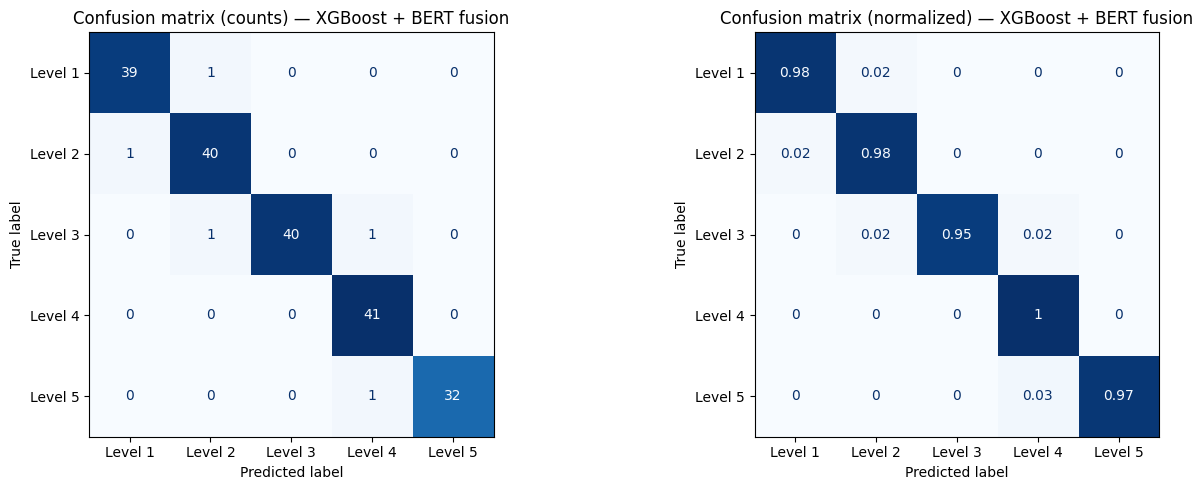

In [13]:
# ── Late fusion: XGBoost + BERT ────────────────────────────────────
late_val_probs_bert  = (xgb_val_probs + bert_val_probs) / 2
late_test_probs_bert = (xgb_test_probs + bert_test_probs) / 2

late_val_preds_bert  = late_val_probs_bert.argmax(axis=1)
late_test_preds_bert = late_test_probs_bert.argmax(axis=1)

# ── Early fusion ───────────────────────────────────────────────────
bert_tr_probs, bert_tr_embs = get_bert_probs_and_embeddings(bert_clf, texts_tr)

early_tr_X_bert   = np.concatenate([bert_tr_embs, X_tr],  axis=1)
early_val_X_bert  = np.concatenate([bert_val_embs, X_val], axis=1)
early_test_X_bert = np.concatenate([bert_test_embs, X_test], axis=1)

INPUT_DIM_BERT = early_tr_X_bert.shape[1]

class EarlyFusionHead(nn.Module):
    def __init__(self, input_dim, num_classes=5, hidden=[256, 128], dropout=0.3):
        super().__init__()
        layers = []
        in_d = input_dim
        for h in hidden:
            layers += [nn.Linear(in_d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_d = h
        layers.append(nn.Linear(in_d, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

fusion_head_bert = EarlyFusionHead(input_dim=INPUT_DIM_BERT).to(DEVICE)

ef_tr_loader_bert  = make_loader(early_tr_X_bert,  y_tr,  shuffle=True)
ef_val_loader_bert = make_loader(early_val_X_bert, y_val)

# ── Train early fusion head ────────────────────────────────────────
EPOCHS_EF_BERT = 20
optimizer_ef_bert = torch.optim.AdamW(fusion_head_bert.parameters(), lr=1e-3, weight_decay=1e-4)
criterion_ef_bert = nn.CrossEntropyLoss()
scheduler_ef_bert = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_ef_bert, T_max=EPOCHS_EF_BERT)

best_val_loss_ef_bert, best_state_ef_bert = float('inf'), None

for epoch in range(1, EPOCHS_EF_BERT + 1):
    fusion_head_bert.train()
    train_loss = 0
    for Xb, yb in ef_tr_loader_bert:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer_ef_bert.zero_grad()
        loss = criterion_ef_bert(fusion_head_bert(Xb), yb)
        loss.backward()
        optimizer_ef_bert.step()
        train_loss += loss.item()
    scheduler_ef_bert.step()

    train_loss /= len(ef_tr_loader_bert)

    # Validation
    fusion_head_bert.eval()
    val_loss, preds, trues = 0, [], []
    with torch.no_grad():
        for Xb, yb in ef_val_loader_bert:
            logits = fusion_head_bert(Xb.to(DEVICE))
            val_loss += criterion_ef_bert(logits, yb.to(DEVICE)).item()
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(yb.numpy())

    val_loss /= len(ef_val_loader_bert)
    f1 = f1_score(trues, preds, average='macro')
    print(f'Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Macro-F1: {f1:.4f}')

    if val_loss < best_val_loss_ef_bert:
        best_val_loss_ef_bert = val_loss
        best_state_ef_bert    = fusion_head_bert.state_dict()

fusion_head_bert.load_state_dict(best_state_ef_bert)
print('Best val loss:', round(best_val_loss_ef_bert, 4))

# ── Early fusion predictions ───────────────────────────────────────
ef_val_preds_bert  = fusion_head_bert(torch.tensor(early_val_X_bert,  dtype=torch.float32).to(DEVICE))
ef_test_preds_bert = fusion_head_bert(torch.tensor(early_test_X_bert, dtype=torch.float32).to(DEVICE))

ef_val_preds_bert  = ef_val_preds_bert.argmax(1).cpu().numpy()
ef_test_preds_bert = ef_test_preds_bert.argmax(1).cpu().numpy()

# ── Results ────────────────────────────────────────────────────────
print('\nResults across models on test set')
for name, p in [('XGBoost only',  xgb_test_probs.argmax(1)),
                ('BERT only',     bert_test_probs.argmax(1)),
                ('Late Fusion',   late_test_preds_bert),
                ('Early Fusion',  ef_test_preds_bert)]:
    f1 = f1_score(y_test.squeeze(), p, average='macro')
    print(f'{name:<20} Macro-F1: {f1:.4f}')

# ── Cost-sensitive score ───────────────────────────────────────────
cost_matrix = np.array([[0, 1, 2, 3, 4],
                         [1, 0, 1, 2, 3],
                         [2, 1, 0, 1, 2],
                         [3, 2, 1, 0, 1],
                         [4, 3, 2, 1, 0]])

def cost_sensitive_score(y_true, y_pred, cost_matrix):
    total_cost = sum(cost_matrix[t][p] for t, p in zip(y_true, y_pred))
    worst_cost = sum(cost_matrix[t].max() for t in y_true)
    return 1 - (total_cost / worst_cost)

score = cost_sensitive_score(y_test.squeeze(), late_test_preds_bert, cost_matrix)
print(f'\nCost-sensitive score (late fusion): {score:.4f}')

# ── Confusion matrix ───────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
CLASS_NAMES = ['Level 1', 'Level 2', 'Level 3', 'Level 4', 'Level 5']

cm      = confusion_matrix(y_test, ef_test_preds_bert)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion matrix (counts) — XGBoost + BERT fusion')

disp_norm = ConfusionMatrixDisplay(np.round(cm_norm, 2), display_labels=CLASS_NAMES)
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion matrix (normalized) — XGBoost + BERT fusion')

plt.tight_layout()
plt.savefig('confusion_matrix_xgb_bert_fusion.png', dpi=150)
plt.show()